In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [2]:
CSV_PATH = "archive/data.csv"
IMAGE_DIR = "archive/image"

df = pd.read_csv(CSV_PATH)
image_column = df.columns[0]

df["image_path"] = df[image_column].astype(str).apply(
    lambda x: os.path.join(IMAGE_DIR, x + ".jpeg")
)
df = df[df["image_path"].apply(os.path.exists)]
print("Total samples:", len(df))

Total samples: 1512


In [3]:
encoder = LabelEncoder()
df["label_encoded"] = encoder.fit_transform(df["classes"])
print("Classes:", encoder.classes_)

Classes: ['bumper_dent' 'bumper_scratch' 'door_dent' 'door_scratch' 'glass_shatter'
 'head_lamp' 'tail_lamp' 'unknown']


In [4]:
IMG_SIZE = 224
images = []
labels = []

for _, row in df.iterrows():
    img = cv2.imread(row["image_path"])
    if img is None:
        continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = preprocess_input(img)
    images.append(img)
    labels.append(row["label_encoded"])

X = np.array(images)
y = np.array(labels)
print("Dataset shape:", X.shape)

Dataset shape: (1512, 224, 224, 3)


In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

Train: (1209, 224, 224, 3)
Validation: (151, 224, 224, 3)
Test: (152, 224, 224, 3)


In [6]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(X_train)

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=True,
    input_shape=(224,224,3)
)

output = Dense(num_classes, activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 82s 1us/step


In [8]:
model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=40,
    callbacks=[early_stop]
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,770,184 (94.49 MB)

 Trainable params: 5,648,136 (21.55 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.2134 - loss: 2.5375 - val_accuracy: 0.4768 - val_loss: 1.4829
Epoch 2/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.3508 - loss: 1.8688 - val_accuracy: 0.5762 - val_loss: 1.2633
Epoch 3/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.4572 - loss: 1.5417 - val_accuracy: 0.6490 - val_loss: 1.1067
Epoch 4/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.5769 - loss: 1.2745 - val_accuracy: 0.6954 - val_loss: 0.9577
Epoch 5/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.5550 - loss: 1.2730 - val_accuracy: 0.7086 - val_loss: 0.8368
Epoch 6/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.6329 - loss: 1.0417 - val_accuracy: 0.7483 - val_loss: 0.7161
Epoch 7/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6775 - loss: 0.9467 - val_accuracy: 0.8079 - val_loss: 0.6454
Epoch 8/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.7215 - loss: 0.7901 - val_accuracy: 0.8079 - val_loss:

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 831ms/step - accuracy: 0.8572 - loss: 0.3925

Model Evaluation
----------------------------
Test Loss     : 0.3935
Test Accuracy : 0.8618
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 799ms/step

Overall Evaluation Metrics
----------------------------
Accuracy  : 0.8618
Precision : 0.8655
Recall    : 0.8618
F1 Score  : 0.8623

Detailed Classification Report
----------------------------
                precision    recall  f1-score   support

   bumper_dent       0.83      0.77      0.80        13
bumper_scratch       0.50      0.50      0.50         8
     door_dent       0.89      0.80      0.84        20
  door_scratch       0.67      0.75      0.71        16
 glass_shatter       0.92      0.85      0.88        13
     head_lamp       0.87      1.00      0.93        13
     tail_lamp       0.87      0.93      0.90        14
       unknown       0.96      0.95      0.95        55

      accuracy                           0.86       152
     macro avg       0.81      0.82    

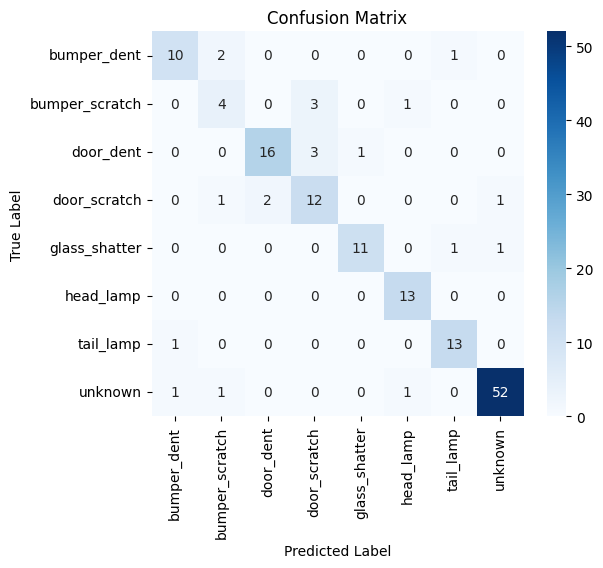

In [11]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print("\nModel Evaluation")
print("----------------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)
y_test_labels = encoder.inverse_transform(y_test)
pred_labels = encoder.inverse_transform(pred_classes)

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\nOverall Evaluation Metrics")
print("----------------------------")

accuracy = accuracy_score(y_test_labels, pred_labels)
precision = precision_score(y_test_labels, pred_labels, average='weighted')
recall = recall_score(y_test_labels, pred_labels, average='weighted')
f1 = f1_score(y_test_labels, pred_labels, average='weighted')

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("\nDetailed Classification Report")
print("----------------------------")
print(classification_report(y_test_labels, pred_labels))

cm = confusion_matrix(y_test_labels, pred_labels)
print("\nConfusion Matrix")
print("----------------------------")
print(cm)


import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()